In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
cust = pd.read_excel(r'C:\Users\paris\Downloads\ecommerce_ml_generated_dataset\data\CustomersData.xlsx')
cust.head(2)

,CustomerID,Gender,Location,Tenure_Months
0,17850,M,Chicago,12
1,13047,M,California,43


In [4]:
discount = pd.read_csv(r'C:\Users\paris\Downloads\ecommerce_ml_generated_dataset\data\Discount_Coupon.csv')
discount.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Month             96 non-null     object
 1   Product_Category  96 non-null     object
 2   Coupon_Code       96 non-null     object
 3   Discount_pct      96 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 3.1+ KB


In [5]:
spend = pd.read_csv(r'C:\Users\paris\Downloads\ecommerce_ml_generated_dataset\data\Marketing_Spend.csv')
spend.head(2)


,Date,Offline_Spend,Online_Spend
0,1/1/2019,4500,2424.50
1,1/2/2019,4500,3480.36


In [6]:
online_sales = pd.read_csv(r'C:\Users\paris\Downloads\ecommerce_ml_generated_dataset\data\Online_Sales.csv')
online_sales.head(2)

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status
0,17850,16679,20190101,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
1,17850,16680,20190101,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used


In [7]:
tax_amt = pd.read_excel(r'C:\Users\paris\Downloads\ecommerce_ml_generated_dataset\data\Tax_amount.xlsx')
tax_amt.head(2)


,Product_Category,Tax
0,Nest-USA,0.1
1,Office,0.1


In [8]:
online_sales_cust = pd.merge(online_sales,cust, on = 'CustomerID',how='left')
o_c_t = pd.merge(online_sales_cust,tax_amt,on ='Product_Category',how='left')
o_c_t.head(5)

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Gender,Location,Tenure_Months,Tax
0,17850,16679,20190101,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,M,Chicago,12,0.10
1,17850,16680,20190101,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,M,Chicago,12,0.10
2,45697,16681,20190630,GGOEGOAQ012899,Google Spiral Notebook and Pen Set,Office,1,8.99,0.00,Used,F,Los Angeles,14,0.10
3,56105,16682,20190527,GGOEGOLC014299,Google Leather Journal,Office,3,19.99,12.99,Used,F,Florida,55,0.10
4,30379,16683,20191101,GGOEGOLC014599,Google Large Notebook,Notebooks,1,11.99,12.99,Clicked,M,Texas,7,0.18


In [9]:
o_c_t.Transaction_Date = pd.to_datetime(
    o_c_t.Transaction_Date.astype(str),
    format="%Y%m%d"
)

In [10]:
o_c_t['tx_month'] = o_c_t.Transaction_Date.dt.strftime("%b")
o_c_t.head(5)

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Gender,Location,Tenure_Months,Tax,tx_month
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,M,Chicago,12,0.10,Jan
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,M,Chicago,12,0.10,Jan
2,45697,16681,2019-06-30,GGOEGOAQ012899,Google Spiral Notebook and Pen Set,Office,1,8.99,0.00,Used,F,Los Angeles,14,0.10,Jun
3,56105,16682,2019-05-27,GGOEGOLC014299,Google Leather Journal,Office,3,19.99,12.99,Used,F,Florida,55,0.10,May
4,30379,16683,2019-11-01,GGOEGOLC014599,Google Large Notebook,Notebooks,1,11.99,12.99,Clicked,M,Texas,7,0.18,Nov


In [11]:
df=pd.merge(o_c_t,discount,left_on=['tx_month','Product_Category'],right_on=['Month','Product_Category'],how='inner')
df.drop("tx_month",axis=1,inplace=True)


In [12]:
df.shape
df.info()
df.isna().sum()
df.duplicated().sum()
df.columns

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1002 entries, 0 to 1001
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           1002 non-null   int64         
 1   Transaction_ID       1002 non-null   int64         
 2   Transaction_Date     1002 non-null   datetime64[ns]
 3   Product_SKU          1002 non-null   object        
 4   Product_Description  1002 non-null   object        
 5   Product_Category     1002 non-null   object        
 6   Quantity             1002 non-null   int64         
 7   Avg_Price            1002 non-null   float64       
 8   Delivery_Charges     1002 non-null   float64       
 9   Coupon_Status        1002 non-null   object        
 10  Gender               1002 non-null   object        
 11  Location             1002 non-null   object        
 12  Tenure_Months        1002 non-null   int64         
 13  Tax                  1002 non-nul

Index(['CustomerID', 'Transaction_ID', 'Transaction_Date', 'Product_SKU',
       'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price',
       'Delivery_Charges', 'Coupon_Status', 'Gender', 'Location',
       'Tenure_Months', 'Tax', 'Month', 'Coupon_Code', 'Discount_pct'],
      dtype='object')

In [13]:
spend['Date']= spend['Date'].apply(lambda x:pd.to_datetime(x))
spend.head(5)

,Date,Offline_Spend,Online_Spend
0,2019-01-01,4500,2424.50
1,2019-01-02,4500,3480.36
2,2019-01-03,4000,2971.21
3,2019-01-04,4500,1549.34
4,2019-01-05,5000,1775.55


In [14]:
#create data audit report for continous variables
def continous_variable_summary(x):
    return pd.Series([x.count(),x.isnull().sum(),x.sum(),x.mean(),x.median(),x.mode(),x.std(),x.min(),x.quantile(0.25),x.quantile(0.50),x.quantile(0.75),x.max()],
                        index=['count','missing_values','sum','mean','median','mode','std','min','P25%','P50%','P75%','max'])

In [15]:
#create data audit report for categorical variables
def categorical_val_summary(x):
    Mode= x.value_counts().sort_values(ascending=False)[0:1].reset_index()
    return pd.Series([x.count(),x.isnull().sum(),Mode.iloc[0,0],Mode.iloc[0,1],round(Mode.iloc[0,1]/x.count()*100,2)],
                     index=['count','missing_values','mode','freq','percent'])

In [16]:
df['Avg_Price'].describe()

count    1002.000000
mean       34.691657
std        47.030265
min         1.500000
25%        11.990000
50%        16.990000
75%        24.990000
max       199.000000
Name: Avg_Price, dtype: float64

In [17]:
continous_variable_summary(df['Avg_Price'])

count                                                   1002
missing_values                                             0
sum                                                 34761.04
mean                                               34.691657
median                                                 16.99
mode              0    12.99
Name: Avg_Price, dtype: float64
std                                                47.030265
min                                                      1.5
P25%                                                   11.99
P50%                                                   16.99
P75%                                                   24.99
max                                                    199.0
dtype: object

In [83]:
#Filling missing/NULL Values
def missing_imputation(x, stats='mean'):

    if pd.api.types.is_numeric_dtype(x):

        if stats == 'mean':
            x = x.fillna(x.mean())
        else:
            x = x.fillna(x.median())

    else:
        x = x.fillna(x.mode().iloc[0])

    return x

In [80]:
df['Revenue'] = (
    (df['Quantity'] * df['Avg_Price'])
    - ((df['Quantity'] * df['Avg_Price']) * df['Discount_pct'] / 100)
    + df['Tax']
    + df['Delivery_Charges']
)
df.head(5)

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Location,Tenure_Months,Tax,Month,Coupon_Code,Discount_pct,Revenue,occurence,Day,Week
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,Chicago,12,0.1,Jan,SALE25,25,121.8825,New,1,1
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,Chicago,12,0.1,Jan,SALE25,25,121.8825,Existing,1,1
2,12671,16762,2019-01-25,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,1,199.00,12.99,Clicked,...,New Jersey,9,0.1,Jan,SALE25,25,162.3400,New,25,4
3,23434,16849,2019-01-07,GGOENEBB078899,Nest Protect Smoke + CO Alarm - USA,Nest-USA,2,119.00,7.99,Not Used,...,Los Angeles,28,0.1,Jan,SALE25,25,186.5900,New,7,2
4,16590,16855,2019-01-29,GGOENEBB078899,Nest Protect Smoke + CO Alarm - USA,Nest-USA,1,119.00,6.50,Not Used,...,Florida,21,0.1,Jan,SALE25,25,95.8500,New,29,5


# Understanding how many customers acquired each month

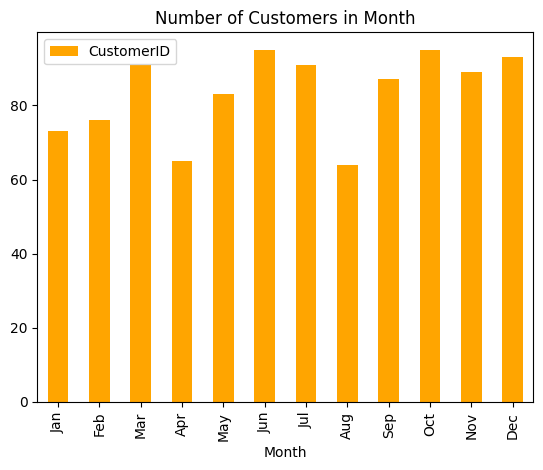

In [20]:
month_order = [
    'Jan','Feb','Mar','Apr','May','Jun',
    'Jul','Aug','Sep','Oct','Nov','Dec'
]

df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)
df.groupby(by='Month')[['CustomerID']].count().plot(kind='bar',title='Number of Customers in Month',color='orange')
plt.show()

# understanding the retention of customers month on month basis

In [21]:
df=df.assign(occurence=np.where (~df['CustomerID'].duplicated(),'New','Existing'))
df.head(5)

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Gender,Location,Tenure_Months,Tax,Month,Coupon_Code,Discount_pct,Revenue,occurence
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,M,Chicago,12,0.1,Jan,SALE25,25,135.31,New
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,M,Chicago,12,0.1,Jan,SALE25,25,135.31,Existing
2,12671,16762,2019-01-25,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,1,199.00,12.99,Clicked,M,New Jersey,9,0.1,Jan,SALE25,25,187.09,New
3,23434,16849,2019-01-07,GGOENEBB078899,Nest Protect Smoke + CO Alarm - USA,Nest-USA,2,119.00,7.99,Not Used,M,Los Angeles,28,0.1,Jan,SALE25,25,221.09,New
4,16590,16855,2019-01-29,GGOENEBB078899,Nest Protect Smoke + CO Alarm - USA,Nest-USA,1,119.00,6.50,Not Used,F,Florida,21,0.1,Jan,SALE25,25,100.60,New


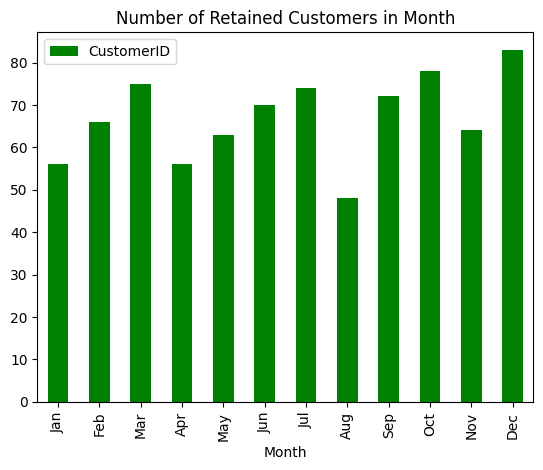

In [ ]:
retention_cust = df[df['occurence']=='Existing'].groupby(by='Month')[['CustomerID']].count()
retention_cust.plot(kind='bar',title='Number of Retained Customers in Month',color='green')
plt.show()

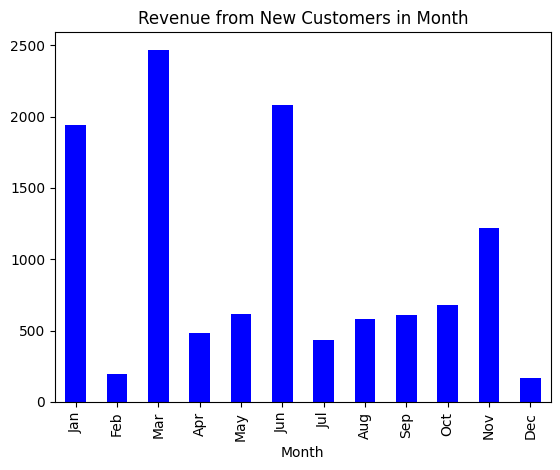

In [81]:
df_new_cust=df.loc[df['occurence']=='New'].copy()
df_new_cust.groupby(by='Month')['Revenue'].sum().plot(kind='bar',title='Revenue from New Customers in Month',color='blue')
plt.show()
        

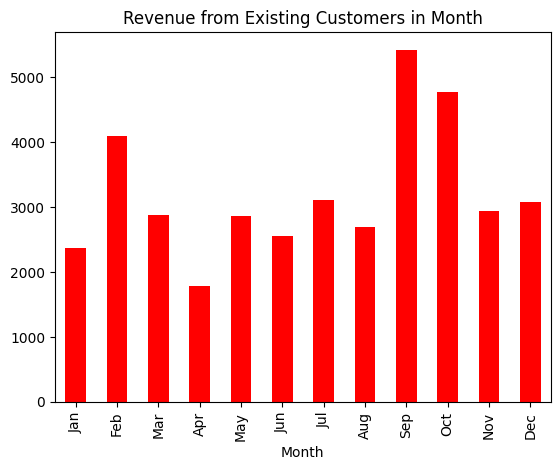

In [ ]:
df_existing_cust=df.loc[df['occurence']=='Existing'].copy()
df_existing_cust.occurence.count()
df_existing_cust.groupby(by='Month')['Revenue'].sum().plot(kind='bar',title='Revenue from Existing Customers in Month',color='red')
plt.show()


# how discount is playing the role in Revenue

In [25]:
df.groupby(by=['Discount_pct'])[['Revenue']].sum()
df['Revenue'].sum()
df.Quantity.count()


1002

In [26]:
df1=df.iloc[:,[0,1,18]]
df1=df.groupby(by=['CustomerID'])[['Transaction_ID']].count()
df1['avg_order_value'] = df.groupby(by=['CustomerID'])['Revenue'].sum()/df1.Transaction_ID
df1


,Transaction_ID,avg_order_value
CustomerID,,
10053,4,29.120000
10464,1,8.160000
10726,3,118.900000
10942,4,11.375000
11504,3,184.106667
...,...,...
98039,8,32.045000
98781,10,45.320000
99192,5,23.598000


In [27]:
df.groupby(by=['Product_Category'])[['Quantity']].sum().sort_values(by='Quantity',ascending=False)

,Quantity
Product_Category,
Bags,256
Notebooks,228
Drinkware,222
Office,218
Apparel,215
Lifestyle,212
Headgear,188
Nest-USA,187


In [82]:
df['Day']=df.Transaction_Date.dt.isocalendar().day
df['Week']=df.Transaction_Date.dt.isocalendar().week
df.head(2)

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Location,Tenure_Months,Tax,Month,Coupon_Code,Discount_pct,Revenue,occurence,Day,Week
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,Chicago,12,0.1,Jan,SALE25,25,121.8825,New,2,1
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,Chicago,12,0.1,Jan,SALE25,25,121.8825,Existing,2,1


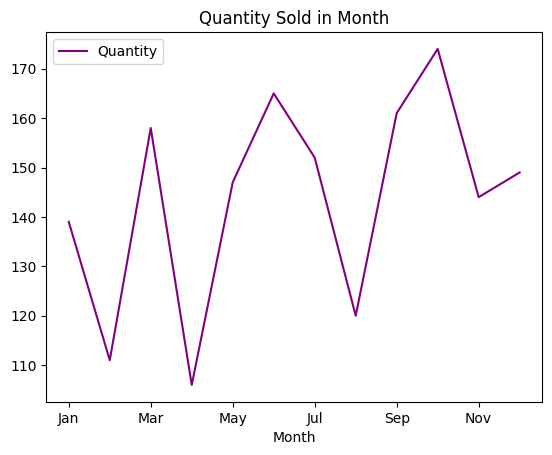

In [29]:
df2= df.groupby(by=['Month'])[['Quantity']].sum().reset_index()
df2.plot(x='Month',y='Quantity',kind='line',title='Quantity Sold in Month',color='purple')
plt.show()



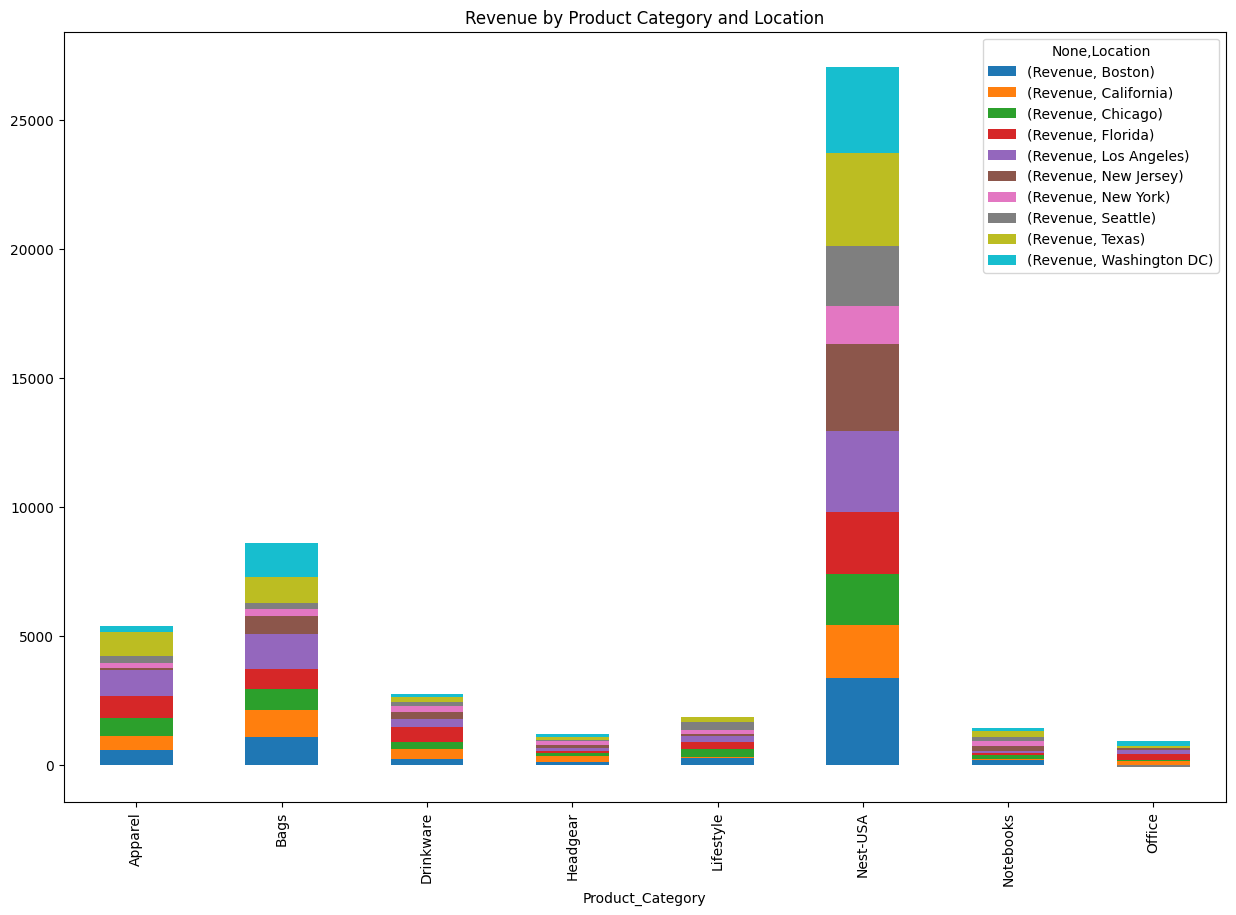

In [35]:
df.groupby(by=['Product_Category','Location'])[['Revenue']].sum().unstack().plot(kind='bar',stacked=True,figsize=(15,10),title='Revenue by Product Category and Location')
plt.show()


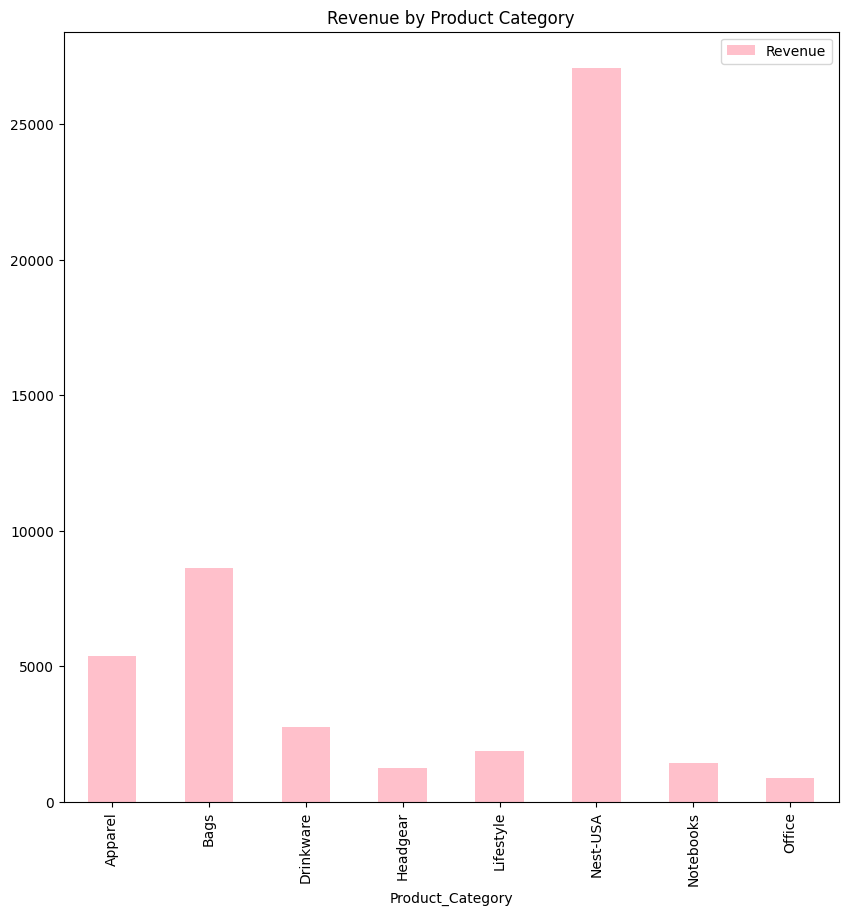

In [37]:
df.groupby(by=['Product_Category'])[['Revenue']].sum().plot(kind='bar',figsize=(10,10),title='Revenue by Product Category',color='pink')
plt.show()

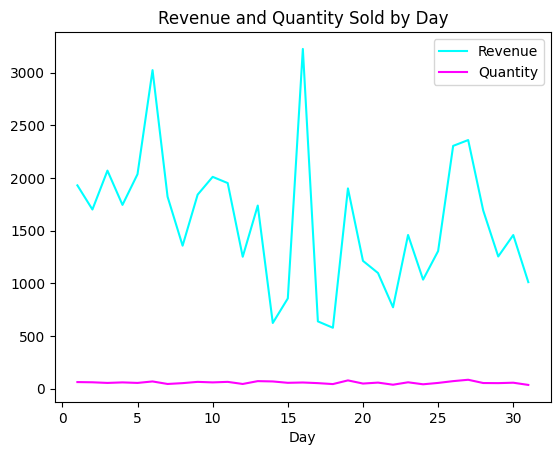

In [49]:
sales = df.groupby(by=['Day']).agg({'Revenue':sum,'Quantity':sum}).reset_index()
sales.plot(x='Day',y=['Revenue','Quantity'],kind='line',title='Revenue and Quantity Sold by Day',color=['cyan','magenta'])
plt.show()

In [63]:
delivery_charges= df.groupby(['Month'])[['Delivery_Charges']].sum()
delivery_charges

,Delivery_Charges
Month,
Jan,520.54
Feb,524.97
Mar,615.87
Apr,435.03
May,568.88
Jun,672.87
Jul,617.87
Aug,457.53
Sep,562.90


In [ ]:
spend['Month']=spend.Date.dt.strftime("%b")
marketing_spend= spend.groupby(by=['Month']).agg({ 'Offline_Spend': sum, 'Online_Spend': sum })
marketing_spend['Total_Marketing_Spend']= marketing_spend.Offline_Spend + marketing_spend.Online_Spend
marketing_spend= marketing_spend.reset_index()

,Month,Offline_Spend,Online_Spend,Total_Marketing_Spend
0,Apr,123500,130973.25,254473.25
1,Aug,134500,106003.74,240503.74
2,Dec,128500,112484.52,240984.52
3,Feb,116000,121785.00,237785.00
4,Jan,123000,108028.07,231028.07


In [76]:
revenue_by_month = df.groupby(by=['Month'])[['Revenue']].sum().reset_index()
revenue_spend= pd.merge(left = revenue_by_month,right = marketing_spend,on=['Month'],how='inner')
revenue_spend['Marketing_Spend_out_of_Revenue_pct'] = (revenue_spend.Total_Marketing_Spend/revenue_spend.Revenue)*100
revenue_spend.head(5)

,Month,Revenue,Offline_Spend,Online_Spend,Total_Marketing_Spend,Marketing_Spend_out_of_Revenue_pct
0,Jan,4574.25,123000,108028.07,231028.07,5050.621851
1,Feb,4141.86,116000,121785.00,237785.00,5741.019735
2,Mar,5601.97,130000,130541.44,260541.44,4650.889598
3,Apr,2196.45,123500,130973.25,254473.25,11585.660953
4,May,3297.37,125500,128271.93,253771.93,7696.192117


In [79]:
df.groupby(by=['Product_Description'])[['Quantity']].sum().sort_values(by='Quantity',ascending=False)

,Quantity
Product_Description,
Google Large Notebook,123
Google Small Notebook,105
Google Laptop Sleeve,103
Google Cap Black,98
Google Hoodie Grey,91
Google Sticker Pack,90
Google Beanie,90
Google Spiral Notebook and Pen Set,85
Google Stainless Steel Bottle,80


# Correlation Analysis

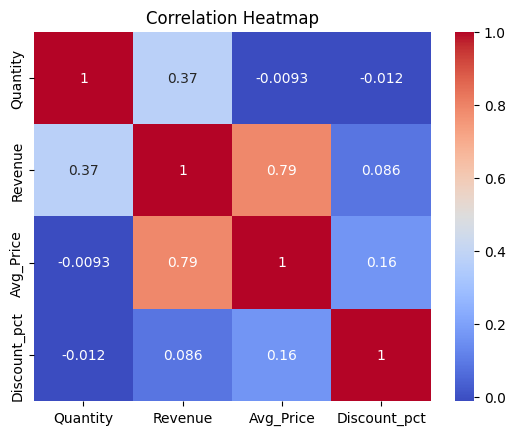

In [87]:
corr = df[['Quantity','Revenue','Avg_Price','Discount_pct']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Outlier Analysis

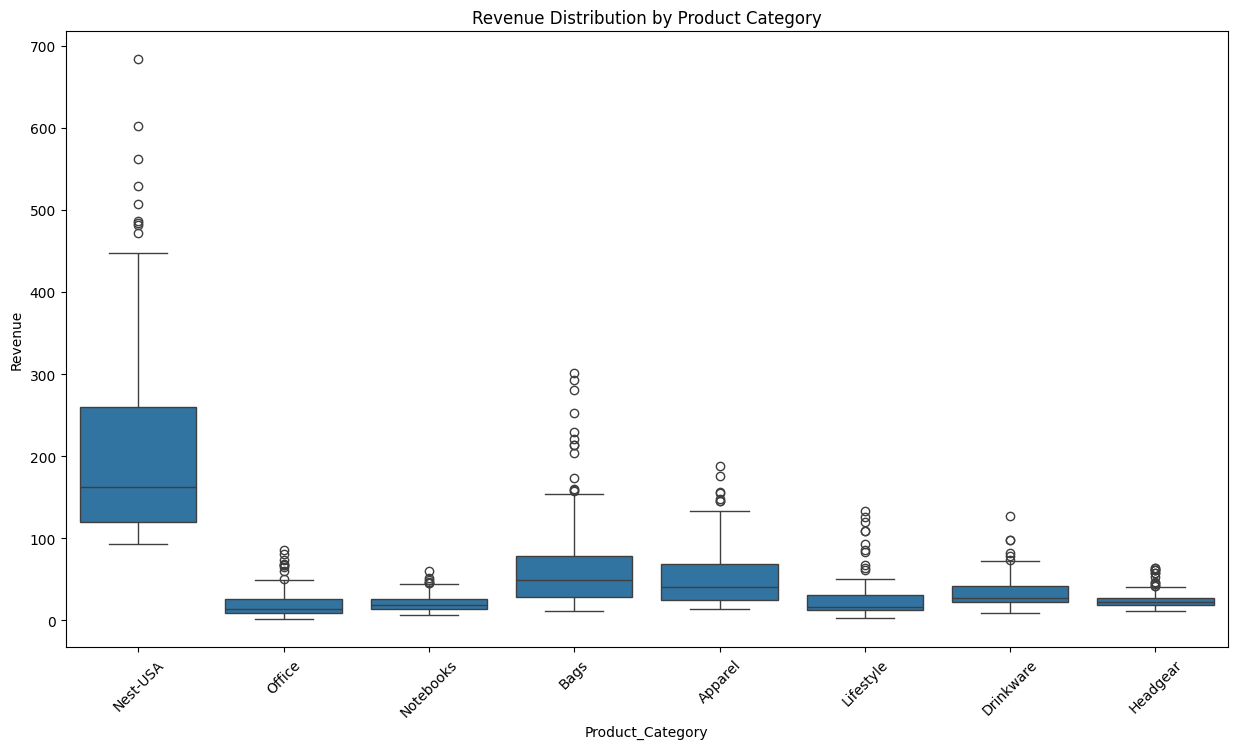

In [94]:
fig, ax = plt.subplots(figsize=(15,8))

sns.boxplot(
    x='Product_Category',
    y='Revenue',
    data=df,
    ax=ax
)

plt.xticks(rotation=45)

plt.title('Revenue Distribution by Product Category')

plt.show()